# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# Rapikan nama kolom agar konsisten dengan penulisan Python
df.columns = df.columns.str.strip().str.lower().str.replace('-', '_', regex=False)

# Hilangkan spasi dan ubah simbol ? menjadi missing value
categorical_columns = df.select_dtypes(include=['object', 'string']).columns
df[categorical_columns] = df[categorical_columns].apply(lambda col: col.str.strip())
df[categorical_columns] = df[categorical_columns].replace('?', np.nan)

print('Ukuran data:', df.shape)
df.info()
display(df.describe(include='all').T)

missing_values = df.isna().sum()
print('\nKolom yang memiliki missing value:')
display(missing_values[missing_values > 0].to_frame('jumlah_missing'))

Ukuran data: (48842, 15)
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital_status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Kolom yang memiliki missing value:


,jumlah_missing
workclass,2799
occupation,2809
native_country,857


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [8]:
# Semua kolom yang missing bersifat kategorikal, sehingga diisi dengan modus
columns_with_missing = df.columns[df.isna().any()]
imputation_values = {
    column: df[column].mode(dropna=True).iloc[0]
    for column in columns_with_missing
}
df = df.fillna(imputation_values)

print('Nilai imputasi:', imputation_values)
print('Total missing value setelah imputasi:', int(df.isna().sum().sum()))
display(df.isna().sum().to_frame('jumlah_missing'))

Nilai imputasi: {'workclass': 'Private', 'occupation': 'Prof-specialty', 'native_country': 'United-States'}
Total missing value setelah imputasi: 0


,jumlah_missing
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [9]:
# Inspeksi nilai unik seluruh fitur kualitatif
categorical_columns = df.select_dtypes(include=['object', 'string']).columns
for column in categorical_columns:
    print(f'{column}: {sorted(df[column].unique())}')

# Samakan label income dari data train dan test yang berbeda karena tanda titik
df['income'] = df['income'].str.rstrip('.')

# Perbaiki kesalahan penulisan nama negara
df['native_country'] = df['native_country'].replace({
    'Columbia': 'Colombia',
    'Holand-Netherlands': 'Holland-Netherlands',
    'Trinadad&Tobago': 'Trinidad&Tobago'
})

# native_country punya cardinality sangat tinggi (41 kategori) dan banyak
# negara yang jumlah sampelnya sangat sedikit sehingga tidak representatif
# jika dibiarkan sebagai kategori terpisah. Kategori dengan proporsi < 0.5%
# dari total data digabung menjadi 'Others'
country_freq = df['native_country'].value_counts(normalize=True) * 100
rare_countries = country_freq[country_freq < 0.5].index
df['native_country'] = df['native_country'].replace(dict.fromkeys(rare_countries, 'Others'))

print(f'\nJumlah kategori native_country yang digabung jadi Others: {len(rare_countries)}')
print('Kategori yang digabung:', sorted(rare_countries.tolist()))

# Inspeksi ulang untuk memastikan hasil pembersihan
print('\nKategori setelah dibersihkan:')
for column in categorical_columns:
    print(f'{column}: {sorted(df[column].unique())}')

print('\nJumlah setiap kategori income:')
display(df['income'].value_counts().to_frame('jumlah'))
assert set(df['income'].unique()) == {'<=50K', '>50K'}

workclass: ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']
education: ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']
marital_status: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
occupation: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']
relationship: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']
race: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
sex: ['Female', 'Male']
native_country: ['Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Dominican-R

,jumlah
income,
<=50K,37155
>50K,11687


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

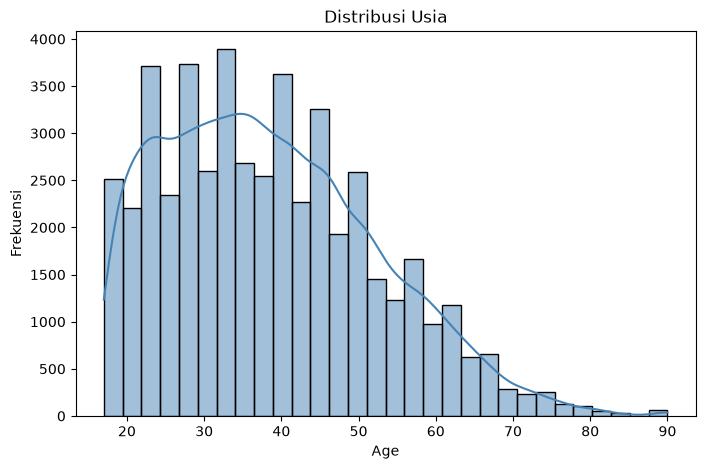

In [10]:
# Jawab 1.1 - Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

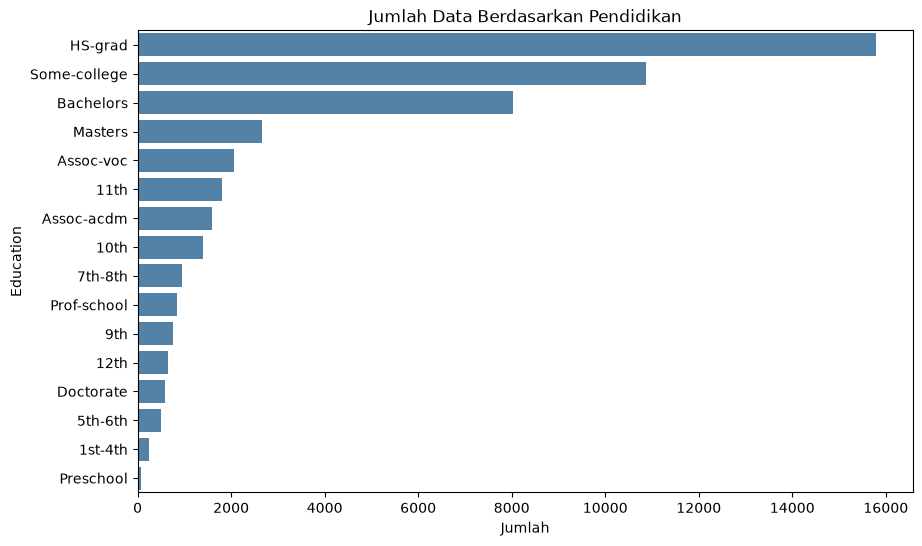

In [11]:
# Jawab 1.2 - Barchart
education_counts = df['education'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=education_counts.values, y=education_counts.index, color='steelblue')
plt.title('Jumlah Data Berdasarkan Pendidikan')
plt.xlabel('Jumlah')
plt.ylabel('Education')
plt.show()

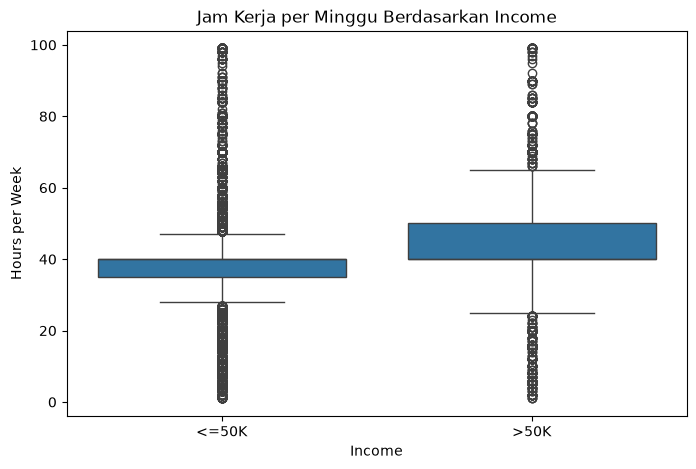

In [12]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours_per_week', order=['<=50K', '>50K'])
plt.title('Jam Kerja per Minggu Berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

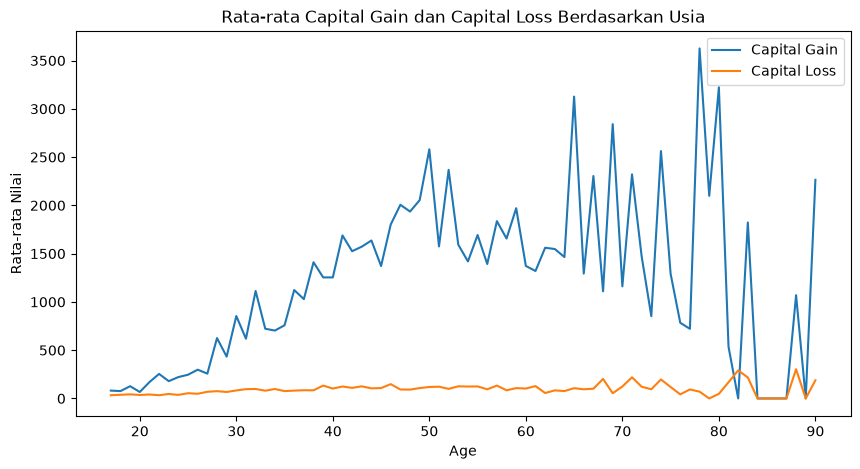

In [13]:
# Jawab 1.4 - Lineplot
capital_by_age = df.groupby('age', as_index=False)[['capital_gain', 'capital_loss']].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(data=capital_by_age, x='age', y='capital_gain', label='Capital Gain')
sns.lineplot(data=capital_by_age, x='age', y='capital_loss', label='Capital Loss')
plt.title('Rata-rata Capital Gain dan Capital Loss Berdasarkan Usia')
plt.xlabel('Age')
plt.ylabel('Rata-rata Nilai')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
# Statistik pendukung untuk analisis distribusi age
age_statistics = pd.Series({
    'mean': df['age'].mean(),
    'median': df['age'].median(),
    'skewness': df['age'].skew()
})
display(age_statistics.to_frame('nilai'))

# Hitung outlier dengan aturan IQR untuk setiap kategori income
outlier_result = []
for income, group in df.groupby('income'):
    q1 = group['hours_per_week'].quantile(0.25)
    q3 = group['hours_per_week'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    total_outlier = ((group['hours_per_week'] < lower_bound) |
                     (group['hours_per_week'] > upper_bound)).sum()
    outlier_result.append([income, lower_bound, upper_bound, total_outlier])

outlier_summary = pd.DataFrame(
    outlier_result,
    columns=['income', 'batas_bawah', 'batas_atas', 'jumlah_outlier']
)
display(outlier_summary)

'''
1. Distribusi age miring ke kanan (positive skew). Sebagian besar usia berada
   pada rentang usia produktif, sedangkan frekuensinya menurun pada usia lanjut.
   Nilai skewness sekitar 0,558; mean 38,64 lebih besar dari median 37.

2. Jika age memiliki missing value, saya menggunakan median karena distribusinya
   miring dan memiliki nilai ekstrem. Median lebih tahan terhadap outlier daripada mean.

3. Berdasarkan metode IQR, kategori <=50K memiliki 11.706 outlier dan kategori
   >50K memiliki 781 outlier. Jadi, kategori <=50K memiliki outlier terbanyak.
'''

,nilai
mean,38.643585
median,37.000000
skewness,0.557580


,income,batas_bawah,batas_atas,jumlah_outlier
0,<=50K,27.5,47.5,11706
1,>50K,25.0,65.0,781


'\n1. Distribusi age miring ke kanan (positive skew). Sebagian besar usia berada\n   pada rentang usia produktif, sedangkan frekuensinya menurun pada usia lanjut.\n   Nilai skewness sekitar 0,558; mean 38,64 lebih besar dari median 37.\n\n2. Jika age memiliki missing value, saya menggunakan median karena distribusinya\n   miring dan memiliki nilai ekstrem. Median lebih tahan terhadap outlier daripada mean.\n\n3. Berdasarkan metode IQR, kategori <=50K memiliki 11.706 outlier dan kategori\n   >50K memiliki 781 outlier. Jadi, kategori <=50K memiliki outlier terbanyak.\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [15]:
# Binary encoding: Female/<=50K = 0 dan Male/>50K = 1
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

display(df[['sex', 'income']].head())
print('Nilai unik sex:', sorted(df['sex'].unique()))
print('Nilai unik income:', sorted(df['income'].unique()))

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


Nilai unik sex: [np.int64(0), np.int64(1)]
Nilai unik income: [np.int64(0), np.int64(1)]


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

,age,education_num,hours_per_week,capital_gain,capital_loss,income
age,1.000,0.031,0.072,0.077,0.057,0.230
education_num,0.031,1.000,0.144,0.125,0.081,0.333
hours_per_week,0.072,0.144,1.000,0.082,0.054,0.228
capital_gain,0.077,0.125,0.082,1.000,-0.031,0.223
capital_loss,0.057,0.081,0.054,-0.031,1.000,0.148
income,0.230,0.333,0.228,0.223,0.148,1.000


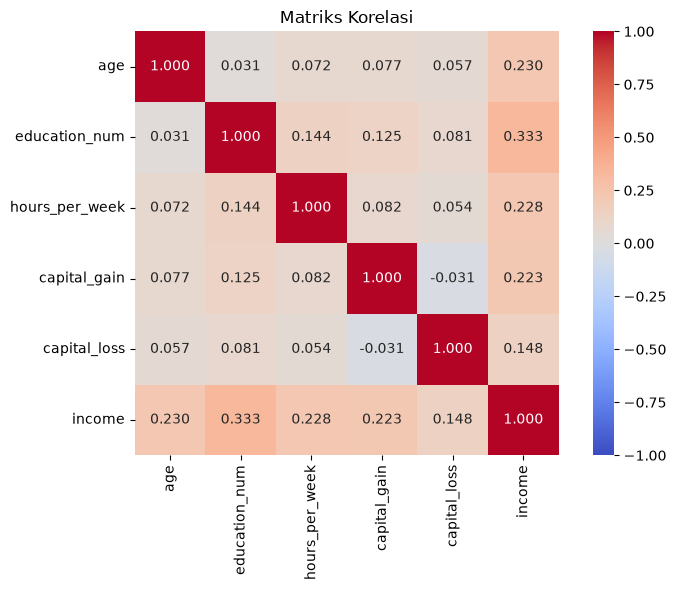

In [16]:
correlation_columns = [
    'age', 'education_num', 'hours_per_week',
    'capital_gain', 'capital_loss', 'income'
]
correlation_matrix = df[correlation_columns].corr()
display(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matriks Korelasi')
plt.tight_layout()
plt.show()

In [17]:
'''
Korelasi dengan income seluruhnya positif, tetapi tidak ada yang kuat.
Education_num memiliki korelasi tertinggi terhadap income (0,333), diikuti
age (0,230), hours_per_week (0,228), capital_gain (0,223), dan
capital_loss (0,148). Artinya, pendidikan yang lebih tinggi paling berkaitan
dengan peluang income >50K di antara variabel yang dianalisis. Namun, korelasi
tidak membuktikan hubungan sebab-akibat. Antarfitur juga berkorelasi lemah,
sehingga tidak terlihat masalah multikolinearitas yang kuat.
'''

'\nKorelasi dengan income seluruhnya positif, tetapi tidak ada yang kuat.\nEducation_num memiliki korelasi tertinggi terhadap income (0,333), diikuti\nage (0,230), hours_per_week (0,228), capital_gain (0,223), dan\ncapital_loss (0,148). Artinya, pendidikan yang lebih tinggi paling berkaitan\ndengan peluang income >50K di antara variabel yang dianalisis. Namun, korelasi\ntidak membuktikan hubungan sebab-akibat. Antarfitur juga berkorelasi lemah,\nsehingga tidak terlihat masalah multikolinearitas yang kuat.\n'

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
# Fetch data and inspect data shape
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dan gunakan 10.000 baris terakhir sebagai data test
X_mnist, y_mnist = fetch_openml(
    'mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto'
)
X_mnist = X_mnist.reshape(-1, 28, 28).astype(np.uint8)
y_mnist = y_mnist.astype(np.uint8)
X_train, y_train = X_mnist[:60000], y_mnist[:60000]
X_test, y_test = X_mnist[60000:], y_mnist[60000:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


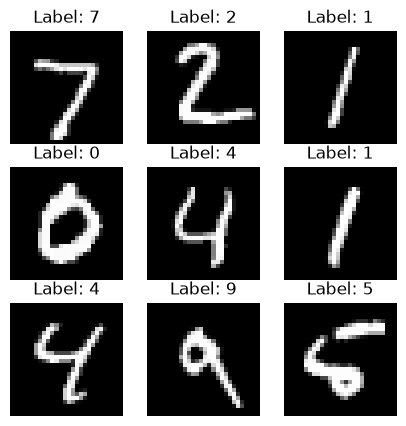

In [19]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape setelah upsampling: (10000, 32, 32)


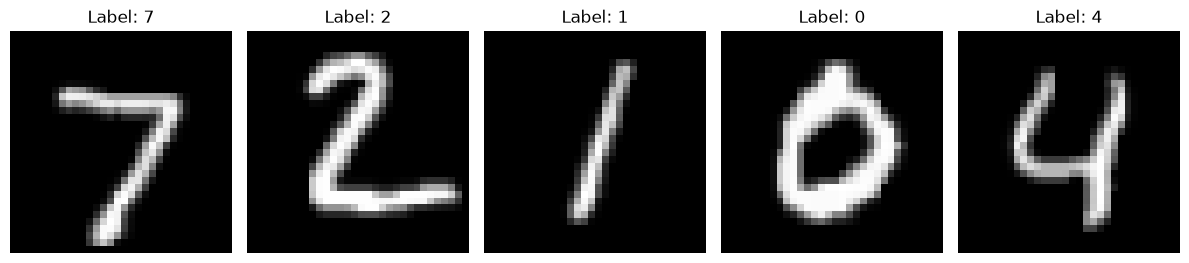

In [20]:
# Resize semua 10.000 citra test dari 28x28 menjadi 32x32
import cv2

X_test_upsampled = np.empty((len(X_test), 32, 32), dtype=np.float32)
for i, image in enumerate(X_test):
    X_test_upsampled[i] = cv2.resize(image, (32, 32), interpolation=cv2.INTER_LINEAR)

print('Shape setelah upsampling:', X_test_upsampled.shape)
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [21]:
# Normalisasi nilai piksel dari 0-255 menjadi 0-1
X_test_normalized = X_test_upsampled / 255.0

print('Nilai minimum:', X_test_normalized.min())
print('Nilai maksimum:', X_test_normalized.max())
print('Shape:', X_test_normalized.shape)

Nilai minimum: 0.0
Nilai maksimum: 1.0
Shape: (10000, 32, 32)


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [22]:
# Ubah setiap citra 32x32 menjadi vektor berukuran 1024
X_test_flattened = np.empty((len(X_test_normalized), 32 * 32), dtype=np.float32)
X_test_flattened[:] = X_test_normalized.reshape(len(X_test_normalized), -1)

print('Shape akhir:', X_test_flattened.shape)
print('Contoh 10 nilai pertama citra pertama:', X_test_flattened[0, :10])

Shape akhir: (10000, 1024)
Contoh 10 nilai pertama citra pertama: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
